MODEL - FREE METHOD (monte carlo)


In [ ]:
from __future__ import annotations

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import random


def build_env(map_name: str = "8x8", slippery: bool = True):
	return gym.make("FrozenLake-v1", map_name=map_name, is_slippery=slippery)


def policy_evaluation_monte_carlo(env, policy, gamma=0.99, episodes=100,max_steps=100, reward_scheme="default"):
	# q value matrix (state, action, (sum of returns, visits))
	Q_values = np.zeros((env.observation_space.n, env.action_space.n,2))

	# exploring
	for episode in range(episodes):
		# choosing a random starting state and action for exploration
		state = random.randint(0, env.observation_space.n - 1)
		action = random.randint(0, env.action_space.n - 1)
		env.reset()
		env.unwrapped.s = state
		done = False
		trajectory = []

		# waling in the env for this episode
		for i in range(max_steps):

			next_state, reward, done, _, _ = env.step(action)

			# triyng out a different reward scheme
			if reward_scheme == "scheme_2":
				if done:
					reward = 1.0 if reward == 1.0 else -1.0
				else:
					reward = -0.01

			trajectory.append((state, action, reward))
			if done:
				break
			state = next_state
			action = policy[state] # now again follwing the greedy policy

		# reward now starts propagating back
		G = 0
		for state, action, reward in reversed(trajectory):
			G = reward + gamma * G
			# reward sum for a particular state action pair
			Q_values[state, action, 0] += G
			# and how many times we visited it
			Q_values[state, action, 1] += 1

	# avg reward
	return Q_values[:,:,0] / np.maximum(Q_values[:,:,1], 1e-8) # 1e-8 is to prevent division by zero


def policy_iteration_monte_carlo(env, gamma=0.99, max_iterations=1000, eval_episodes=200, reward_scheme = "default"):
	n_states = env.observation_space.n
	policy = np.zeros(n_states, dtype=int) # zero (left) initialization

	reward_history = []
	length_history = []

	for iteration in range (max_iterations):
		# evaluation of the current policy
		Q_table = policy_evaluation_monte_carlo(env, policy, gamma, episodes=eval_episodes, max_steps=100, reward_scheme = reward_scheme)
		# improvemnet of the policy (completely greedy) - pick the action that gives max avg reward
		new_policy = np.argmax(Q_table, axis=1)

		# testing our new policy
		test_episodes = 20
		total_rewards = 0
		total_steps = 0

		for _ in range(test_episodes):
			state, _ = env.reset()
			done = False
			while not done:
				action = new_policy[state]
				res = env.step(action)
				state, reward, terminated, truncated = res[0], res[1], res[2], res[3] if len(res)==5 else False
				done = terminated or truncated
				total_rewards += reward
				total_steps += 1

		# tracking for plotting later
		reward_history.append(total_rewards / test_episodes)
		length_history.append(total_steps / test_episodes)

		# checking for early convergence
		if np.array_equal(new_policy, policy):
			return new_policy, reward_history, length_history

		policy = new_policy

	return policy, reward_history, length_history


def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
	desc = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid = np.asarray(policy).reshape(desc.shape)
	arrows = np.array(["<", "v", ">", "^"])
	colors = {
		"S": "#9be7a1",
		"F": "#dceefb",
		"H": "#3a3a3a",
		"G": "#ffd54f",
	}

	fig, ax = plt.subplots(figsize=(8, 8))
	for r in range(desc.shape[0]):
		for c in range(desc.shape[1]):
			tile = desc[r, c]
			rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
			ax.add_patch(rect)

			if tile == "H":
				label = "H"
			elif tile == "G":
				label = "G"
			elif tile == "S":
				label = f"S{arrows[policy_grid[r, c]]}"
			else:
				label = arrows[policy_grid[r, c]]

			ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

	ax.set_xlim(0, desc.shape[1])
	ax.set_ylim(0, desc.shape[0])
	ax.set_xticks(np.arange(desc.shape[1] + 1))
	ax.set_yticks(np.arange(desc.shape[0] + 1))
	ax.grid(True, color="black", linewidth=1.0)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	ax.set_aspect("equal")
	ax.set_title(title)
	plt.tight_layout()
	plt.show()


def main(gamma=0.99, slippery = False, reward_scheme = "default"):
		gamma = gamma
		env = build_env(slippery=slippery)
		# transition, reward, expected_reward = extract_model(env)

		print("FrozenLake-v1 8x8 model")
		# print(f"states: {transition.shape[0]}, actions: {transition.shape[1]}")
		# print("Legend: S=start, F=frozen, H=hole, G=goal, arrow=optimal action")

		mc_policy, rewards, lengths = policy_iteration_monte_carlo(env, gamma=gamma, max_iterations=300, eval_episodes=400, reward_scheme = reward_scheme)

		fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

		ax1.plot(rewards, color='green')
		ax1.set_title("Rewards vs Iterations")
		ax1.set_xlabel("Iterations")
		ax1.set_ylabel("Mean Reward")
		ax1.grid(True, linestyle="--")

		ax2.plot(lengths, color='blue')
		ax2.set_title("Steps vs Iterations")
		ax2.set_xlabel("Iterations")
		ax2.set_ylabel("Mean Steps")
		ax2.grid(True, linestyle="--")

		plt.tight_layout()
		plt.show()

		plot_policy_on_frozen_lake(env, mc_policy, title="Model-Free Monte Carlo Greedy Policy Map")



FrozenLake-v1 8x8 model


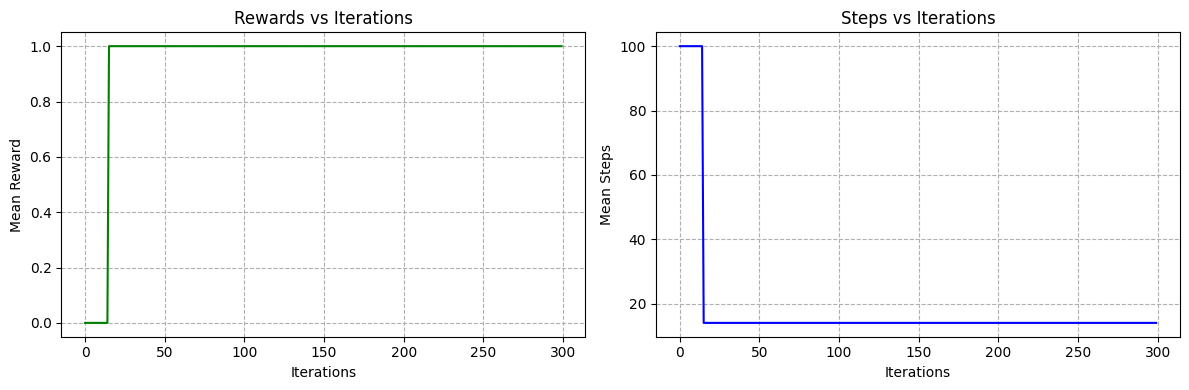

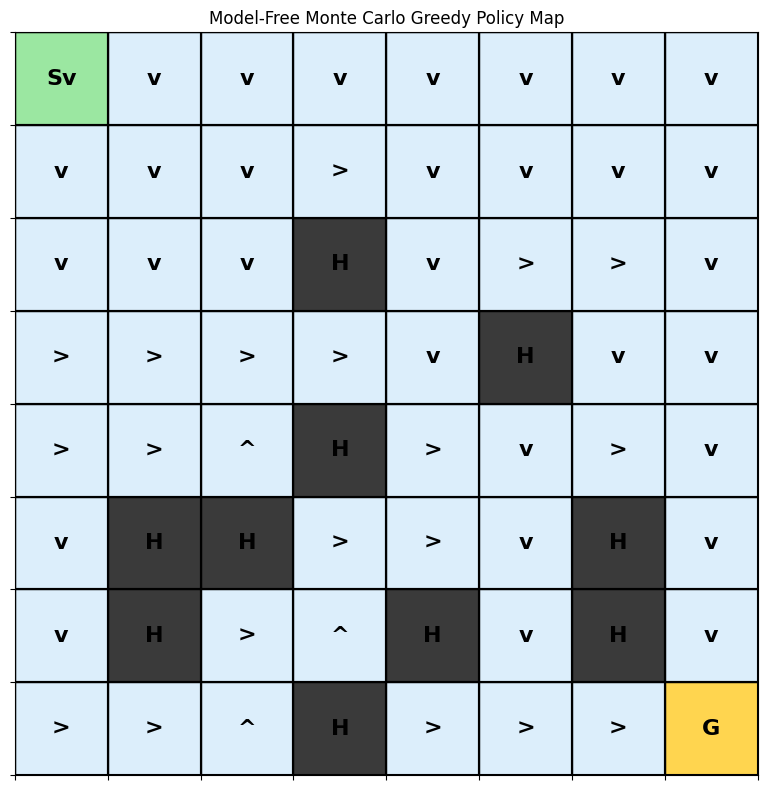

In [18]:
if __name__ == "__main__":
	main(0.99, False)

FrozenLake-v1 8x8 model


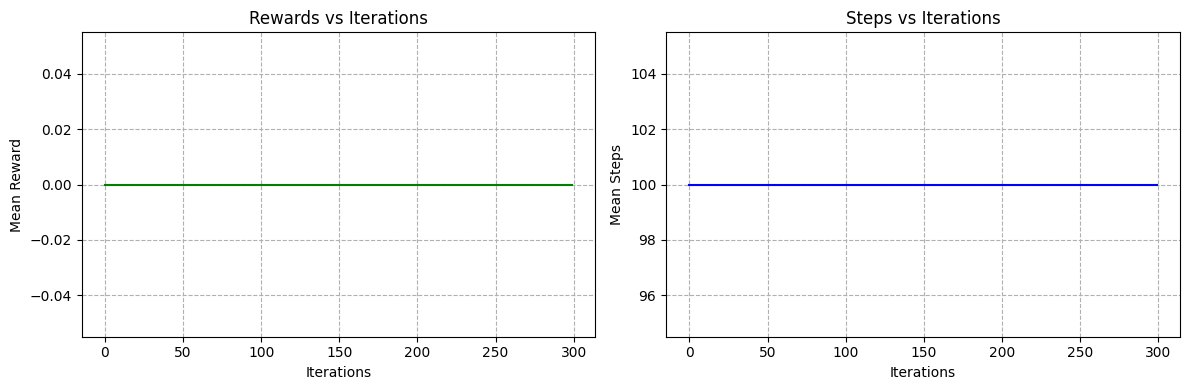

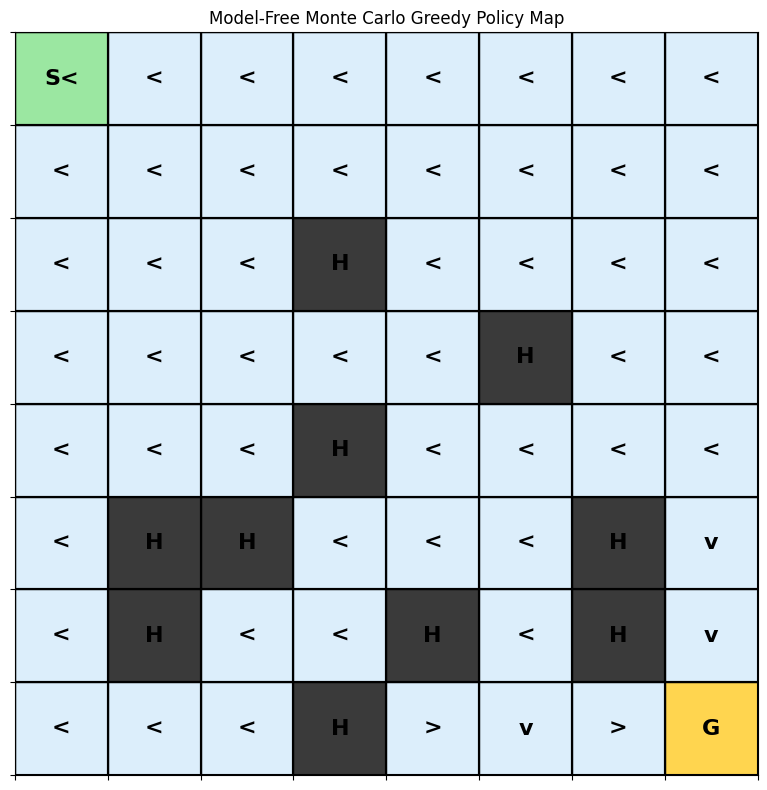

In [13]:
if __name__ == "__main__":
	main(0.99, True)

FrozenLake-v1 8x8 model


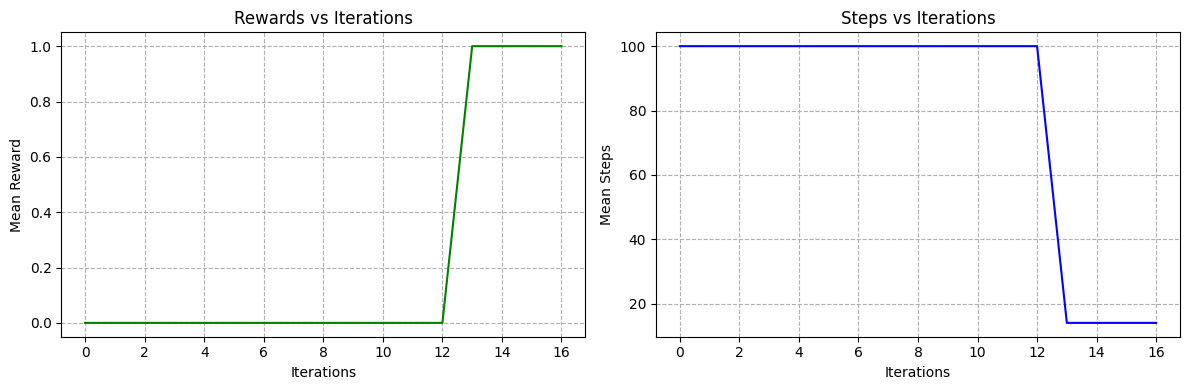

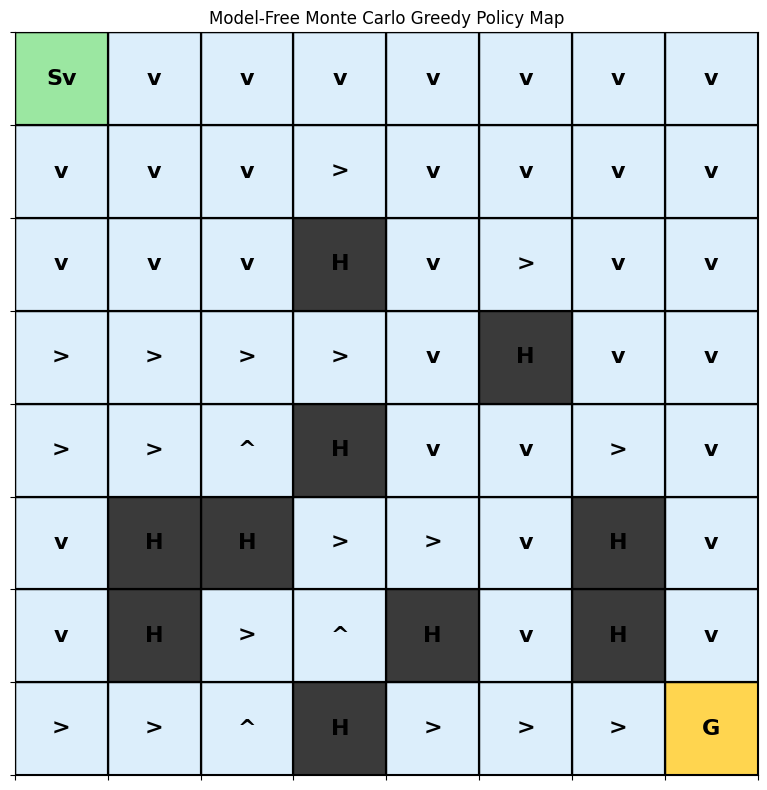

In [14]:
if __name__ == "__main__":
	main(0.5, False)

FrozenLake-v1 8x8 model


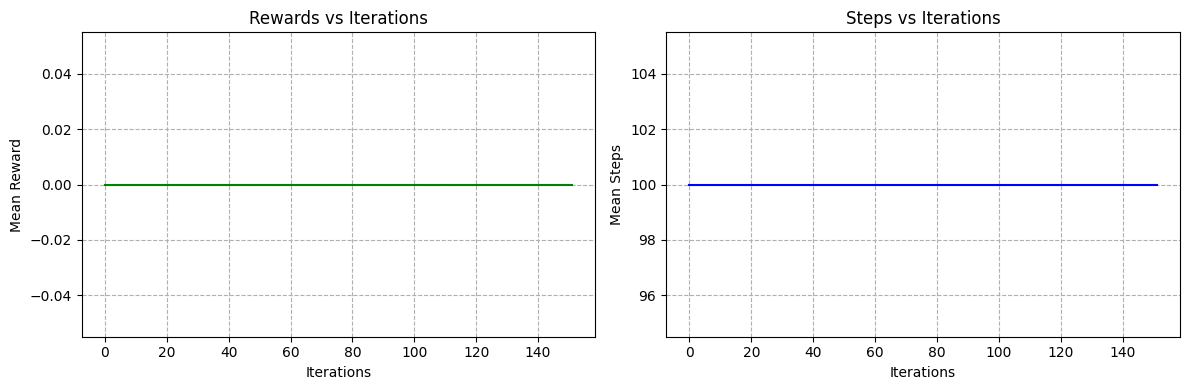

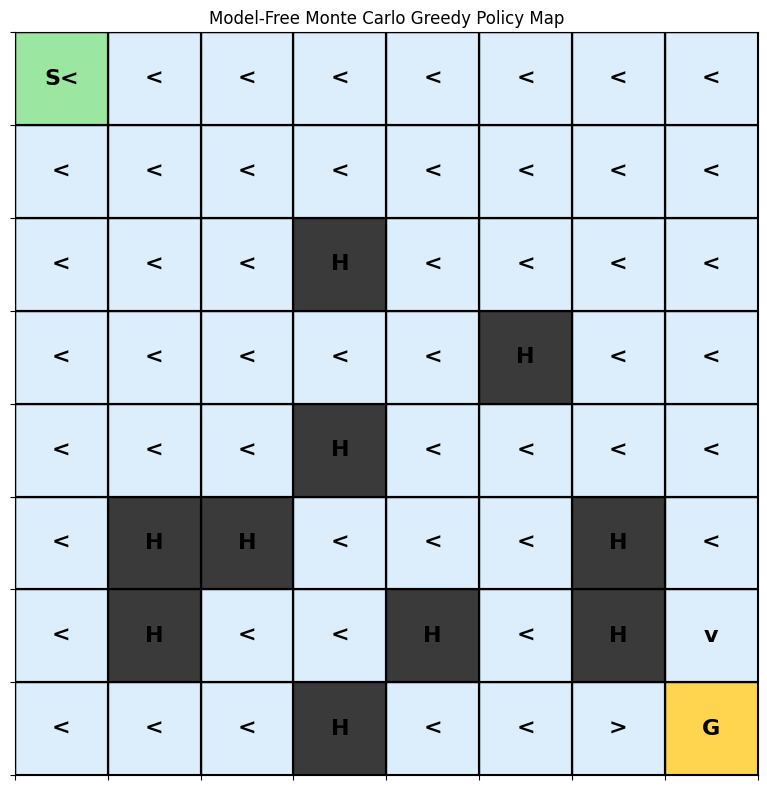

In [15]:
if __name__ == "__main__":
	main(0.5, True)

### 1. gamma = 0.99, slippery = false

Because slippery is false the environment is completely deterministic. 
The first around 10-15 steps the agent has not learned anything, its going with the default move (left) for all 100 steps, then suddenly in the next step it figures out the ultimate best/ shortest strategy which is continued for the rest of the iterations.

how is it finding that best strategy?

ans: as the initial state and action of the agent is decided randomly, at some instant it will land on the tile just left of the goal and as the env is deterministic if it moves right it will get a massive reward. Now on the next iteration if lands one tile further away as the policy is greedy it will surely move right and thsi is how this propagates and hence the best strategy is found.

### 2. gamma = 0.99, slippery = true

With slippery set to true now the environment has become stochastic. we can see from the plot that the agent is unable to learn the optimal strategy even after all the iterations.

why, what difference is slipper = true causing?

ans: just like before the agent randomly lands on the tile next to the goal, it takes a random step (eg right) to walk to the goal. Now there is a 66% chance that the agent slips and doesn't reaches the goal. Now for teh rest of the steps the steps the greedy algorithm takes over and the agent just keeps walking left. because it slips away on the first step, it almost never hits the goal. and even if it does hit the goal, on that rare occasion the reward gets heavily diluted by the thousands of other episodes where it slipped and failed. Therefore, the q value never becomes stable or high enough to change the arrow from left to right.


### 3. gamma = 0.5, slippery = false

Here the policy converges in 17 iterations only (ie the q table stopped changing). 

why did this not happen when gamma was 0.99 but happens in this case?

ans: as 0.5 is small as the number of steps increases its value in the q updation formula decreases rapidly which was not the case for 0.99

### 4. gamma - 0.5, slippery = true

its behaviour is alomst idetical to the case of slippery = true with gamma 0.99 because making the env stochastic with a greedy policy is preventing the agent from learning anything meaningful so changing gamma causes no major difference.





FrozenLake-v1 8x8 model


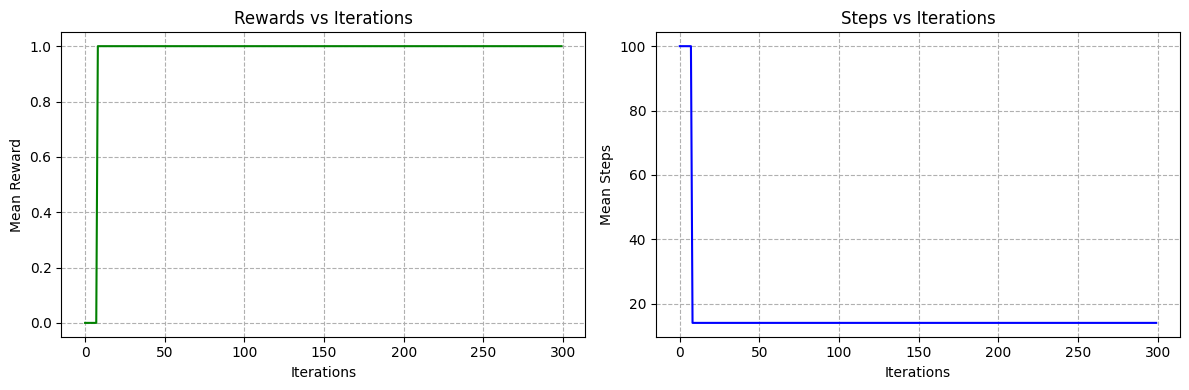

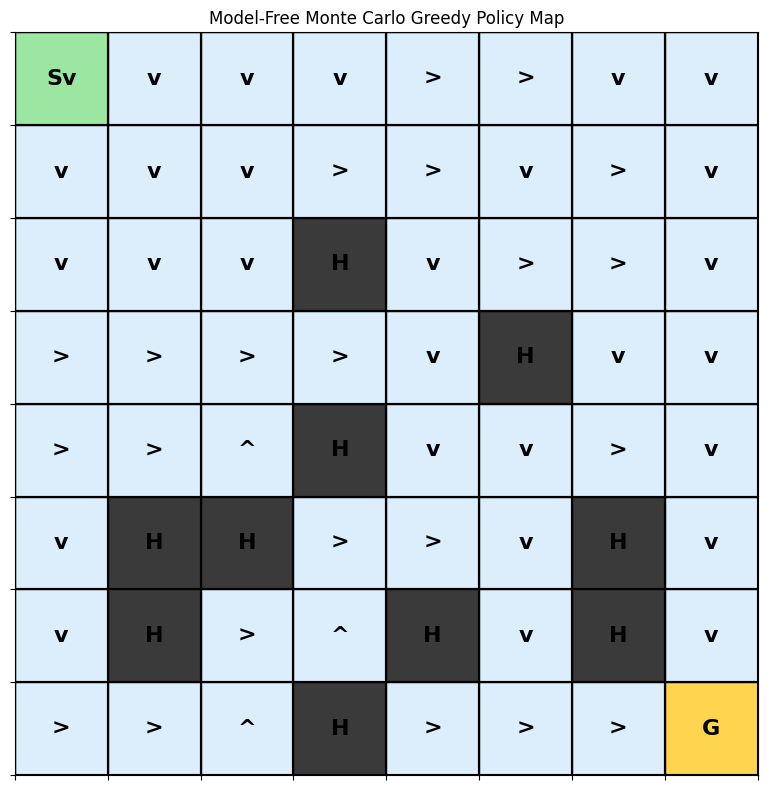

In [19]:
if __name__ == "__main__":
	main(0.99, False, reward_scheme = "scheme_2")

this custom scheme works faster than the default one.

initially taking a longer part had no difference compared to taking a shorter path as long as both give same return but now we changed that so the agent learns faster